In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [133]:
df = pd.read_csv('FutureModelPredictionData.csv')
df

,MedianEarnings,year,state_po,district,CollegeGrad,NonCollegeGrad,MedianAge,Hispanic,White,Black,NativeAmerican,Asian,republican_president,midterm,pvi,Republican Prob
0,45852.42,2026,AL,1,27.72,72.28,41.1,4.0,63.8,26.1,0.5,1.6,True,True,27.0,0.999964
1,45010.78,2026,AL,2,25.70,74.29,39.0,5.2,58.8,30.3,0.2,1.4,True,True,-5.0,0.027647
2,48269.22,2026,AL,3,25.79,74.21,40.1,4.2,67.0,23.2,0.2,1.6,True,True,23.0,0.999825
3,44203.06,2026,AL,4,20.50,79.51,40.8,8.1,80.6,6.3,0.3,0.8,True,True,33.0,0.999998
4,54706.60,2026,AL,5,38.20,61.80,39.4,7.0,68.6,17.4,0.3,2.0,True,True,15.0,0.993313
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,63374.22,2026,WI,5,41.55,58.45,43.0,6.0,85.9,1.8,0.1,3.0,True,True,11.0,0.965117
431,54009.12,2026,WI,6,30.01,70.00,42.7,6.0,86.0,2.0,0.3,2.6,True,True,8.0,0.897692
432,51646.38,2026,WI,7,26.71,73.29,45.3,3.0,89.4,0.4,1.6,1.5,True,True,11.0,0.963980
433,54609.08,2026,WI,8,29.29,70.71,41.5,6.7,83.7,1.5,1.8,2.5,True,True,8.0,0.879807


## Simulating 2026 Outcomes

In [134]:
num_simulations = 50000
simulationDict = {
    'Republican Seats' : [],
    'Democratic Seats' : []
}
np.random.seed(28)

for _ in range(num_simulations):
    randomNum = np.random.rand()
    numWins = (df['Republican Prob'] > randomNum).sum()
    numLosses = 435 - numWins
    simulationDict['Republican Seats'].append(numWins)
    simulationDict['Democratic Seats'].append(numLosses)

simulationDF = pd.DataFrame(simulationDict)

winCount = (simulationDF['Republican Seats'] >= 218).sum()
republicanProb = (winCount/num_simulations) * 100
democraticProb = 100 - republicanProb

print("Democrats have a ", democraticProb, "% chance of flipping the House of Representatives.")
print("Republicans have a ", republicanProb, "% chance of holding the House of Representatives.")


Democrats have a  72.946 % chance of flipping the House of Representatives.
Republicans have a  27.054000000000002 % chance of holding the House of Representatives.


In [135]:
simulationDF['Margin'] = simulationDF['Republican Seats'] - simulationDF['Democratic Seats']
simulationDF.describe()
#simulationDF

,Republican Seats,Democratic Seats,Margin
count,50000.000000,50000.000000,50000.000000
mean,195.687920,239.312080,-43.624160
std,38.481878,38.481878,76.963756
min,2.000000,42.000000,-431.000000
25%,176.000000,216.000000,-83.000000
50%,200.000000,235.000000,-35.000000
75%,219.000000,259.000000,3.000000
max,393.000000,433.000000,351.000000


## Forecast Visualizations

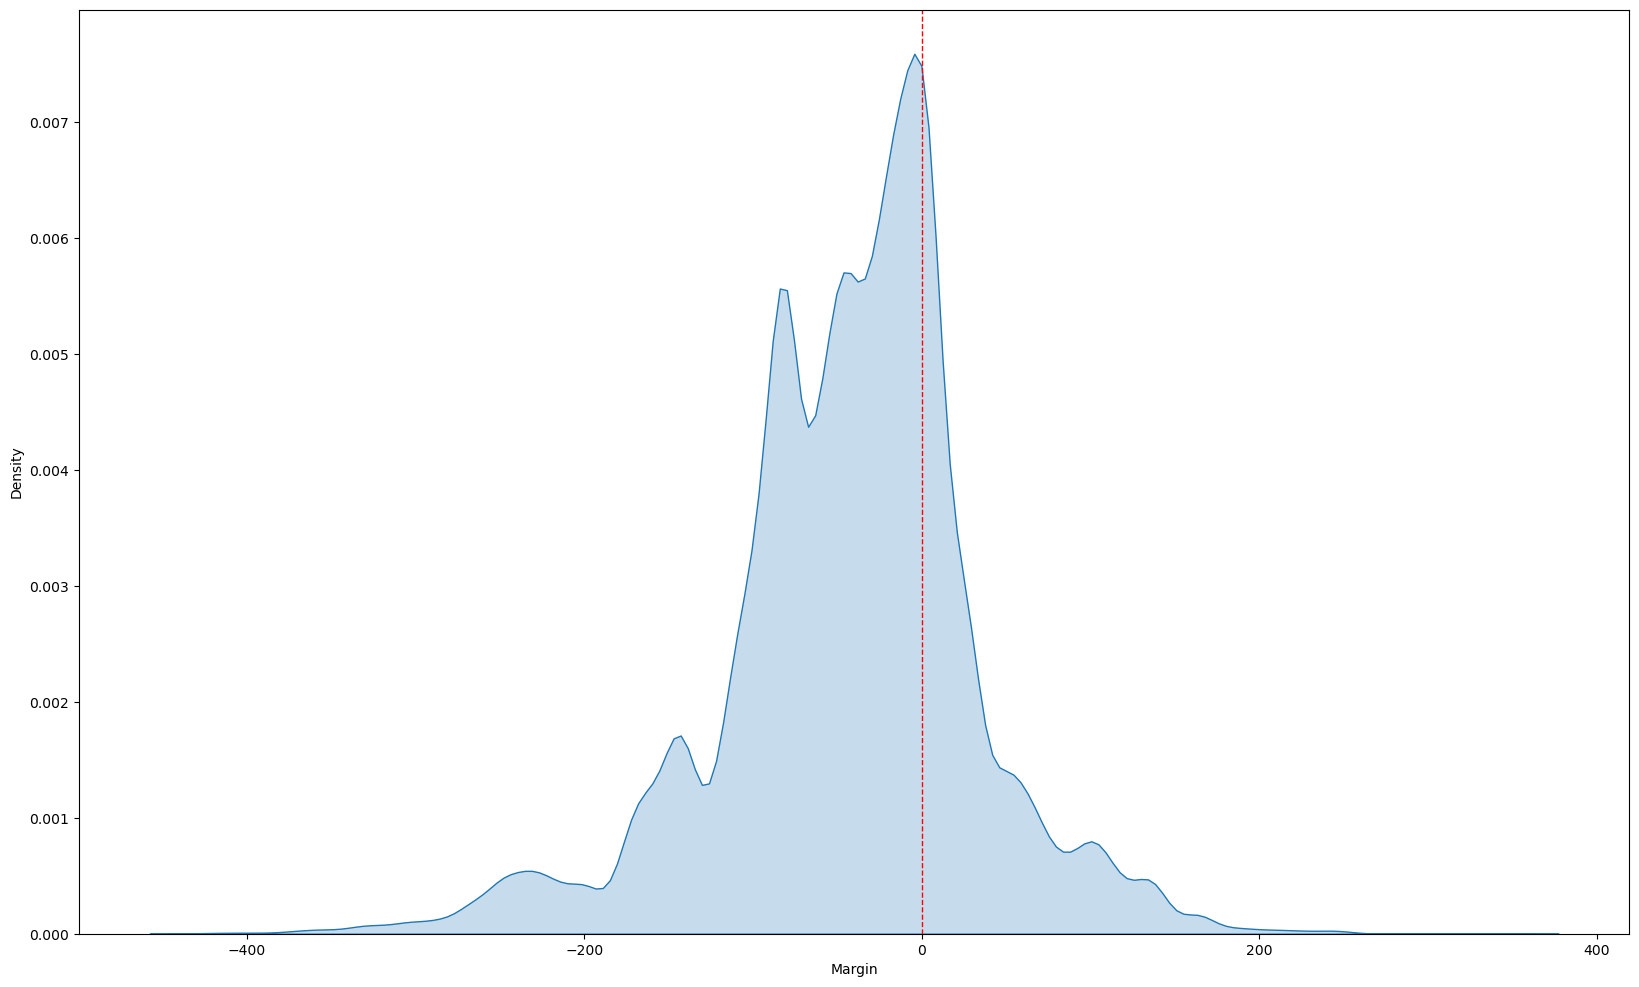

In [136]:
plt.figure(figsize=(20,12))
sns.kdeplot(data=simulationDF['Margin'], fill=True)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)

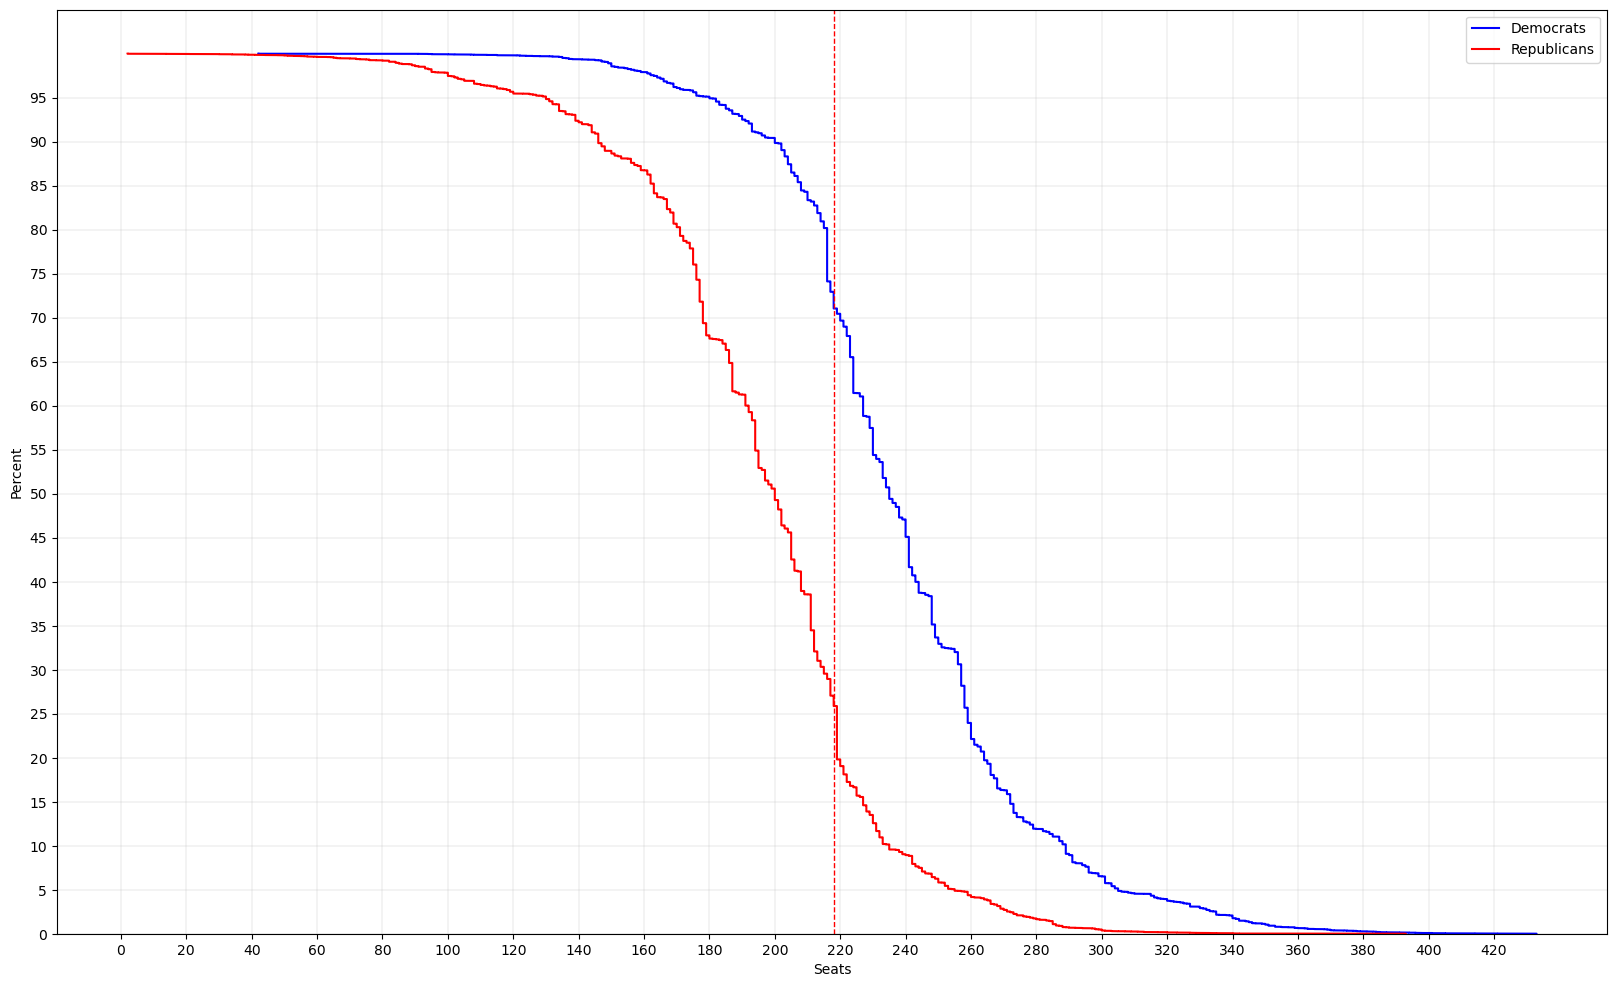

In [137]:
plt.figure(figsize=(20,12))
sns.ecdfplot(data=simulationDF['Democratic Seats'], stat='percent', complementary=True, label= 'Democrats', color='blue')
sns.ecdfplot(data=simulationDF['Republican Seats'], stat='percent', complementary=True, label='Republicans', color='red')
plt.xticks(np.arange(0, 435, 20))
plt.yticks(np.arange(0, 100, 5))
plt.xlabel('Seats')
plt.grid(True, linewidth = 0.2)
plt.legend()

plt.axvline(x=218, color='red', linestyle='--', linewidth=1)

## District Ratings

In [142]:
filteredDF = df[(df['Republican Prob'] < 0.85) & (df['Republican Prob'] > 0.15)]
filteredDF = filteredDF.drop(['MedianEarnings', 'year', 'CollegeGrad', 'NonCollegeGrad', 'MedianAge', 'Hispanic', 'White', 'Black', 'NativeAmerican', 'Asian', 'republican_president', 'midterm'], axis=1)
filteredDF

,state_po,district,pvi,Republican Prob
7,AK,0,6.0,0.320227
8,AZ,1,1.0,0.189643
9,AZ,2,7.0,0.289273
13,AZ,6,0.0,0.155564
23,CA,3,2.0,0.309942
...,...,...,...,...
407,VA,5,6.0,0.742937
416,WA,3,2.0,0.409459
418,WA,5,5.0,0.693162
426,WI,1,2.0,0.408727


In [143]:
def rating(prob):
    if 0.15 <= prob < 0.3:
        return "Likely D"
    elif 0.3 <= prob < 0.45:
        return "Lean D"
    elif 0.45 <= prob < 0.5:
        return "Tilt D"
    elif 0.5 <= prob < 0.55:
        return "Tilt R"
    elif 0.55 <= prob < 0.7:
        return "Lean R"
    else:
        return "Likely R"

In [144]:
filteredDF['Rating'] = filteredDF['Republican Prob'].apply(rating)
filteredDF

,state_po,district,pvi,Republican Prob,Rating
7,AK,0,6.0,0.320227,Lean D
8,AZ,1,1.0,0.189643,Likely D
9,AZ,2,7.0,0.289273,Likely D
13,AZ,6,0.0,0.155564,Likely D
23,CA,3,2.0,0.309942,Lean D
...,...,...,...,...,...
407,VA,5,6.0,0.742937,Likely R
416,WA,3,2.0,0.409459,Lean D
418,WA,5,5.0,0.693162,Lean R
426,WI,1,2.0,0.408727,Lean D


In [162]:
ratingDF = filteredDF.drop(['pvi'], axis=1)
ratingDF['district'] = ratingDF['district'].astype(str)
ratingDF['District'] = ratingDF['state_po'] + '-' + ratingDF['district']
ratingDF = ratingDF.drop(['state_po', 'district'], axis=1)
ratingDF

,Republican Prob,Rating,District
7,0.320227,Lean D,AK-0
8,0.189643,Likely D,AZ-1
9,0.289273,Likely D,AZ-2
13,0.155564,Likely D,AZ-6
23,0.309942,Lean D,CA-3
...,...,...,...
407,0.742937,Likely R,VA-5
416,0.409459,Lean D,WA-3
418,0.693162,Lean R,WA-5
426,0.408727,Lean D,WI-1
